# Jigsaw · completed system and research decisions

**Completed deliverable:** an evaluated rule-conditioned NLP system, a reproducible engineering implementation, and an evidence-backed research portfolio. **Retained result:** 0.91808 public / 0.91425 private ROC AUC, from a successful late Kaggle evaluation. No original competition placement is claimed.

This short review reads three published aggregate receipts. It does not load a model or connect to AWS. The official score receipt was verified on **September 10, 2026**; the latest cross-model research summary is dated **October 6, 2026**. Re-execution renders existing evidence and does not generate a new score.

[Case study](../CASE_STUDY.md) · [Public reproduction contract](../docs/REPRODUCIBILITY.md) · [Model limitations](../MODEL_CARD.md)

In [1]:
from pathlib import Path
import sys
import json
import html
import plotly.graph_objects as go
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / "scripts/review_portfolio.py").is_file():
    if ROOT.parent == ROOT:
        raise RuntimeError("Open this notebook within the repository checkout")
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from scripts.review_portfolio import evidence

summary = evidence(ROOT)
print("Official score verified:", summary["official_verified_utc"])
print("Research receipt:", summary["frontier_receipt_utc"])
print("Private AUC improvement:", f"{summary['private_gain']:+.5f}")
print("Portfolio deliverable complete; future research remains optional.")

Official score verified: 2026-09-10T02:20:43+00:00
Research receipt: 2026-10-06T02:30:00Z
Private AUC improvement: +0.29469
Portfolio deliverable complete; future research remains optional.


## 1. The delivered result

A lexical reference scored 0.61956 private ROC AUC. Support adaptation with Qwen3-4B raised it to **0.91425**, a **+0.29469** absolute gain. The end-to-end comparison changes the backbone and training method together; the separate matched 4B experiment isolates adaptation.

These are successful **late** Kaggle evaluations. Public and private splits are labeled individually; AUC measures ranking and is not an accuracy percentage. The retained rank scores are not calibrated probabilities.

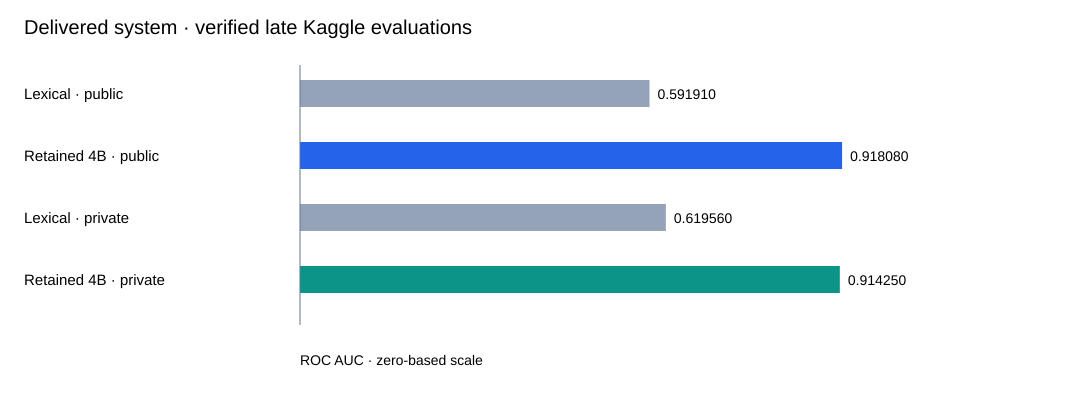

In [2]:
def show_chart(section, title, axis, limits, colors):
    labels = summary[section]["labels"]
    values = summary[section]["values"]
    fig = go.Figure(go.Bar(
        x=values, y=labels, orientation="h", marker_color=colors,
        text=[f"{v:.6f}" for v in values], textposition="outside",
        cliponaxis=False,
    ))
    fig.update_layout(
        template="plotly_white", title=title, height=410, width=1080,
        margin=dict(l=245, r=100, t=75, b=65), showlegend=False,
        xaxis=dict(title=axis, range=list(limits), zeroline=True),
        yaxis=dict(autorange="reversed"),
    )
    low, high = limits
    def x(value):
        return 300 + 620 * (value - low) / (high - low)
    zero = x(0)
    svg = ['<svg xmlns="http://www.w3.org/2000/svg" width="1080" height="410" viewBox="0 0 1080 410">',
           '<rect width="1080" height="410" fill="white"/>',
           f'<text x="24" y="34" font-family="Arial" font-size="20">{html.escape(title)}</text>']
    for i, (label, value, color) in enumerate(zip(labels, values, colors, strict=True)):
        y = 80 + i * 62
        edge = x(value)
        svg += [f'<text x="24" y="{y+19}" font-family="Arial" font-size="15">{html.escape(label)}</text>',
                f'<rect x="{min(zero, edge):.2f}" y="{y}" width="{abs(edge-zero):.2f}" height="27" fill="{color}"/>',
                f'<text x="{edge + (8 if value >= 0 else -8):.2f}" y="{y+19}" text-anchor="{"start" if value >= 0 else "end"}" font-family="Arial" font-size="14">{value:.6f}</text>']
    svg += [f'<line x1="{zero:.2f}" x2="{zero:.2f}" y1="65" y2="325" stroke="#64748b"/>',
            f'<text x="300" y="365" font-family="Arial" font-size="14">{html.escape(axis)}</text>',
            '</svg>']
    display({"application/vnd.plotly.v1+json": fig.to_plotly_json(),
             "image/svg+xml": "".join(svg)}, raw=True)

show_chart("official", "Delivered system · verified late Kaggle evaluations",
           "ROC AUC · zero-based scale", (0, 1.05),
           ["#94a3b8", "#2563eb", "#94a3b8", "#0d9488"])

## 2. A newer model does not automatically replace the delivered system

The later research cohort contains **881 comments and two policies**. It has been repeatedly inspected and is not an untouched holdout. Its policy-macro AUC cannot be compared directly with the official scores above.

The five-backbone development incumbent remains separate from the scored 4B system. The chart below compares each transfer experiment with its **own matched native control**. Fixed-teacher and anchored transfer use the E48 native continuation; reciprocal learning uses its E31 peer control.

All three variants were **valid negatives** under their registered promotion gates. Reciprocal learning had a small positive point estimate, but its 95% interval crossed zero. The chart does not imply that all controls or uncertainty estimates are interchangeable.

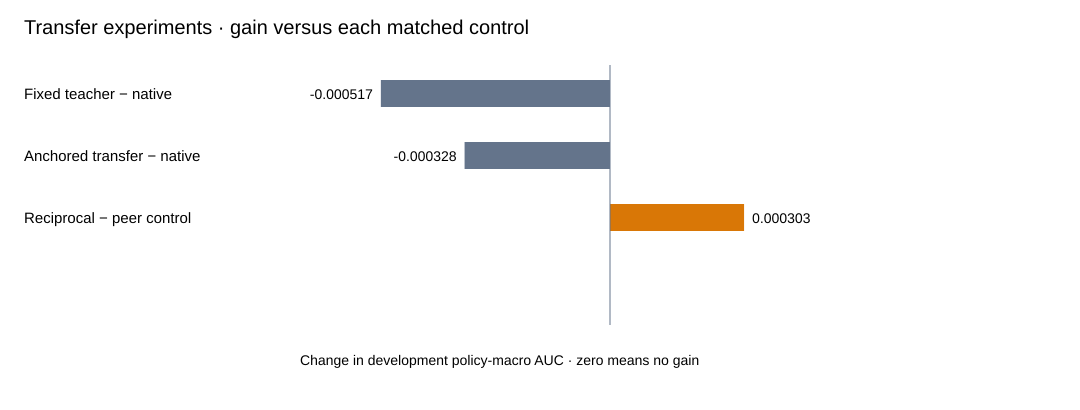

Reciprocal-learning 95% interval: [-0.00051183, 0.00120533]
Fraction of positive bootstrap draws: 0.769
Decisions: fixed teacher, anchored transfer, reciprocal learning = valid negatives


In [3]:
show_chart("development", "Transfer experiments · gain versus each matched control",
           "Change in development policy-macro AUC · zero means no gain", (-0.0007, 0.0007),
           ["#64748b", "#64748b", "#d97706"])
print("Reciprocal-learning 95% interval:", summary["reciprocal_ci95"])
print("Fraction of positive bootstrap draws:", summary["reciprocal_positive_fraction"])
print("Decisions: fixed teacher, anchored transfer, reciprocal learning = valid negatives")

## 3. Completion and reproducibility

| Completed and reviewable | Boundary |
| --- | --- |
| Scored 4B system and lexical baseline | Exact late-evaluation receipts; no medal or production-deployment claim |
| Reusable validation, metric and runtime code | Locked environment, regression tests, resumability and immutable identities |
| Current aggregate review and historical notebooks | Saved Plotly and SVG output; CI execution and save/reopen verification |
| Frontier experiment record | Matched controls and negative findings; no unscored ensemble promoted as a hidden-score winner |

The public repository supports **component and aggregate-evidence reproduction**. Full competitive replay requires privately retained data, row-level predictions, model state and exact ensemble construction. Existing public code/configuration is not made secret by this boundary.

E44 paired-demonstration adaptation is marked **planned in AWS** by the latest receipt. This publication does not establish that it ran or that any AWS space is currently running. No training or submission is required to review the finished deliverable.

Winner-inspired adaptation and representation ideas are attributed in [top-solution integration](../docs/TOP_SOLUTION_INTEGRATION.md). Author contributions include the validation design, implementation, controlled comparisons, AWS execution/recovery and publication system.

In [4]:
print("PUBLIC_REVIEW_SUMMARY=" + json.dumps(summary, sort_keys=True))

PUBLIC_REVIEW_SUMMARY={"development": {"labels": ["Fixed teacher \u2212 native", "Anchored transfer \u2212 native", "Reciprocal \u2212 peer control"], "values": [-0.0005174169999999645, -0.0003283639999999144, 0.0003027389999999963]}, "development_cohort": {"policies": 2, "rows": 881}, "frontier_receipt_utc": "2026-10-06T02:30:00Z", "next_study": {"id": "E44", "status": "planned_in_aws"}, "official": {"labels": ["Lexical \u00b7 public", "Retained 4B \u00b7 public", "Lexical \u00b7 private", "Retained 4B \u00b7 private"], "values": [0.59191, 0.91808, 0.61956, 0.91425]}, "official_verified_utc": "2026-09-10T02:20:43+00:00", "private_gain": 0.29469, "reciprocal_ci95": [-0.00051183, 0.00120533], "reciprocal_positive_fraction": 0.769, "scope": "Completed public evidence review; no training or new hidden evaluation"}
